# Dimensions

../output_results/E_sent/main-2\lat_sc_100_2026-04-30_11-03-04_e-50_s-30_spatial.json
['spatial', 'lat-sc', '100']
../output_results/E_sent/main-2\lat_sc_25_2026-05-01_07-39-56_e-50_s-30_spatial.json
['spatial', 'lat-sc', '25']
../output_results/E_sent/main/lat_sc_2026-04-30_08-23-34_e-50_s-30_spatial.json
['spatial', 'lat-sc', '50']
[0 1 2] ['snn-spa-lat-sc-100', 'snn-spa-lat-sc-25', 'snn-spa-lat-sc-50'] [0.9774604358714766, 0.8374806841796771, 0.9268396653700645] [0.7529976019184652, 0.6853717026378897, 0.720863309352518]


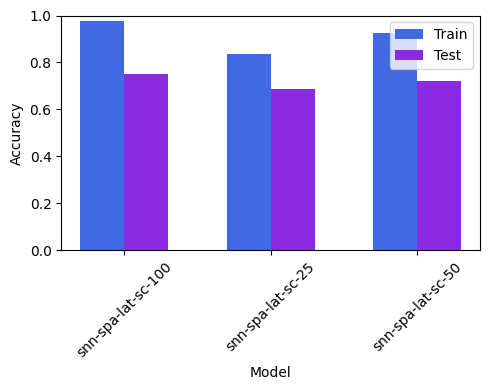

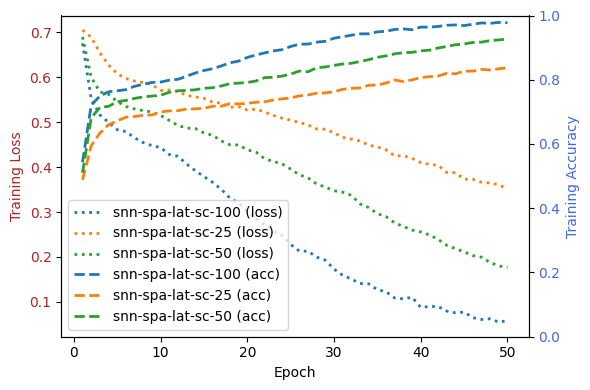

Writing accuracies to ..\output_results\E_sent\main-2\eval\snn_accuracies.tsv
Model	Train	Test	Training duration (min)
snn-spa-lat-sc-100	0.9775	0.7530	38.55
snn-spa-lat-sc-25	0.8375	0.6854	34.96
snn-spa-lat-sc-50	0.9268	0.7209	39.83


In [17]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import numpy as np

from viz_util import colors, ModelNameConvention

files = sorted(glob('../output_results/E_sent/main-2/*.json'))
if not files:
    raise FileNotFoundError('No matching files found')
files.append('../output_results/E_sent/main/lat_sc_2026-04-30_08-23-34_e-50_s-30_spatial.json') #append 50d

file_labels = []
train_accuracies = []
test_accuracies = []
training_duration_min = []
epoch_losses_list = []
epoch_accuracies_list = []

for file_path in files:
    print(file_path)
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    file_name = Path(file_path).name
    label_parts = [data.get('training_config', {}).get('input_mode'), 'lat-sc', str(data.get('training_config', {}).get('embedding_dim'))]
    print(label_parts)
    label = '_'.join(label_parts)
    file_labels.append('snn-' + ModelNameConvention(label))
    train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    test_accuracies.append(data['results']['test_accuracy'])
    training_duration_min.append(data['training_config']['training_duration_s'] / 60.0)
    epoch_losses_list.append(data['results']['epoch_train_loss'])
    epoch_accuracies_list.append(data['results']['epoch_train_accuracy'])

# First plot: bar chart
x = np.arange(len(files))
print(x, file_labels, train_accuracies, test_accuracies)
width = 0.3

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width / 2, train_accuracies, width, label='Train', color=colors.train_accuracy)
ax.bar(x + width / 2, test_accuracies, width, label='Test', color=colors.test_accuracy)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(file_labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Second plot: lines with dual y-axis (loss and accuracy over epochs)
fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot loss on left y-axis
for loss_vals, label in zip(epoch_losses_list, file_labels):
    epochs = np.arange(1, len(loss_vals) + 1)
    ax1.plot(epochs, loss_vals, linestyle=':', label=f'{label} (loss)', linewidth=2)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=colors.loss)
ax1.tick_params(axis='y', labelcolor=colors.loss)

# Create right y-axis for accuracy
ax2 = ax1.twinx()
for acc_vals, label in zip(epoch_accuracies_list, file_labels):
    epochs = np.arange(1, len(acc_vals) + 1)
    ax2.plot(epochs, acc_vals, linestyle='--', label=f'{label} (acc)', linewidth=2)

ax2.set_ylabel('Training Accuracy', color=colors.train_accuracy)
ax2.tick_params(axis='y', labelcolor=colors.train_accuracy)
ax2.set_ylim(0, 1)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.show()

out_dir = Path(files[0]).parent / "eval"
out_dir.mkdir(exist_ok=True)
out_file_path = out_dir / 'snn_accuracies.tsv'
print(f'Writing accuracies to {out_file_path}')
with open(out_file_path, 'w', encoding='utf-8') as summary_file:
     summary_file.write('Model\tTrain accuracy\tTest accuracy\tTraining duration (min)\n')
     for label, train_accuracy, test_accuracy, duration_min in zip(file_labels, train_accuracies, test_accuracies, training_duration_min):
         summary_file.write(f'{label}\t{train_accuracy*100:.2f}\t{test_accuracy*100:.2f}\t{duration_min:.2f}\n')

print('Model\tTrain\tTest\tTraining duration (min)')
for label, train_accuracy, test_accuracy, duration_min in zip(file_labels, train_accuracies, test_accuracies, training_duration_min):
    print(f'{label}\t{train_accuracy:.4f}\t{test_accuracy:.4f}\t{duration_min:.2f}')

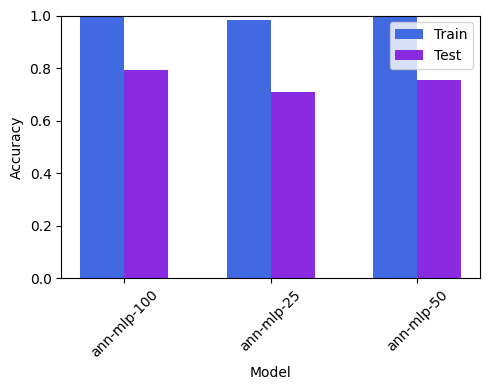

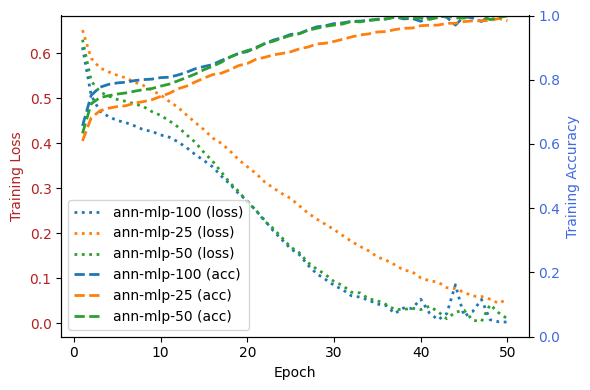

Writing accuracies to ..\output_results\E_sent\ANN\eval\ann_accuracies.tsv
Model	Train	Test	Training duration (min)
ann-mlp-100	1.0000	0.7923	1.12
ann-mlp-25	0.9836	0.7084	0.80
ann-mlp-50	0.9986	0.7530	0.87


In [5]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import numpy as np
from datetime import datetime

from viz_util import colors

files = sorted(glob('../output_results/E_sent/ANN/*.json'))
if not files:
    raise FileNotFoundError('No matching files found')

file_labels = []
train_accuracies = []
test_accuracies = []
training_duration_min = []
epoch_losses_list = []
epoch_accuracies_list = []

for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    file_name = Path(file_path).name
    label_parts = str(Path(file_path).stem).split('_')[0:3]
    label_parts[-1] = label_parts[-1].replace('d', '')
    file_labels.append('-'.join(label_parts))
    train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    test_accuracies.append(data['results']['test_accuracy'])

    start = datetime.strptime(data['training_config']['training_start_date'], '%Y-%m-%d %H:%M:%S')
    end = datetime.strptime(data['training_config']['training_end_date'], '%Y-%m-%d %H:%M:%S')

    training_duration_min.append((end - start).total_seconds() / 60.0)
    epoch_losses_list.append(data['results']['epoch_train_loss'])
    epoch_accuracies_list.append(data['results']['epoch_train_accuracy'])

# First plot: bar chart
x = np.arange(len(files))
width = 0.3

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width / 2, train_accuracies, width, label='Train', color=colors.train_accuracy)
ax.bar(x + width / 2, test_accuracies, width, label='Test', color=colors.test_accuracy)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(file_labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Second plot: lines with dual y-axis (loss and accuracy over epochs)
fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot loss on left y-axis
for loss_vals, label in zip(epoch_losses_list, file_labels):
    epochs = np.arange(1, len(loss_vals) + 1)
    ax1.plot(epochs, loss_vals, linestyle=':', label=f'{label} (loss)', linewidth=2)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=colors.loss)
ax1.tick_params(axis='y', labelcolor=colors.loss)

# Create right y-axis for accuracy
ax2 = ax1.twinx()
for acc_vals, label in zip(epoch_accuracies_list, file_labels):
    epochs = np.arange(1, len(acc_vals) + 1)
    ax2.plot(epochs, acc_vals, linestyle='--', label=f'{label} (acc)', linewidth=2)

ax2.set_ylabel('Training Accuracy', color=colors.train_accuracy)
ax2.tick_params(axis='y', labelcolor=colors.train_accuracy)
ax2.set_ylim(0, 1)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.show()

out_dir = Path(files[0]).parent / "eval"
out_dir.mkdir(exist_ok=True)
out_file_path = out_dir / 'ann_accuracies.tsv'
print(f'Writing accuracies to {out_file_path}')
with open(out_file_path, 'w', encoding='utf-8') as summary_file:
     summary_file.write('Model\tTrain accuracy\tTest accuracy\tTraining duration (min)\n')
     for label, train_accuracy, test_accuracy, duration_min in zip(file_labels, train_accuracies, test_accuracies, training_duration_min):
         summary_file.write(f'{label}\t{train_accuracy*100:.2f}\t{test_accuracy*100:.2f}\t{duration_min:.2f}\n')

print('Model\tTrain\tTest\tTraining duration (min)')
for label, train_accuracy, test_accuracy, duration_min in zip(file_labels, train_accuracies, test_accuracies, training_duration_min):
    print(f'{label}\t{train_accuracy:.4f}\t{test_accuracy:.4f}\t{duration_min:.2f}')

### SNN & ANN models by dim

{'alpha': 'None',
 'batch_size': 32,
 'beta': '0.95',
 'decoding_method': 'spike_count',
 'device': 'cuda',
 'diagnose': False,
 'diagnose_dir': '/content/snn4nlp/output_results/E_sent/diagnostics',
 'embedding_dim': 100,
 'encoding_method': 'latency',
 'energy_ac_cost_pj': 25.63,
 'epochs': 50,
 'estimate_energy': True,
 'eval': 'True',
 'input_file_prefix': 'sent_d100',
 'input_mode': 'spatial',
 'input_size': 1000,
 'learn_beta': 'False',
 'learn_threshold': 'False',
 'learning_rate': '0.0001',
 'limit': None,
 'model_path': 'f:\\KU\\Thesis\\Project\\Code\\output_results\\E_sent\\main-2\\lat_sc_100_2026-04-30_11-03-04_e-50_s-30_spatial.pt',
 'neuron_model': 'lif',
 'num_hidden_1': 256,
 'num_hidden_2': 128,
 'num_labels': 2,
 'num_test_samples': 2085,
 'num_training_samples': 18767,
 'output_dir': '/content/snn4nlp/output_results/E_sent',
 'output_file_prefix': 'lat_sc_100',
 'output_json': None,
 'save': 'True',
 'sequence_length': 10,
 'sim_steps': 30,
 'split': 'test',
 'task': '

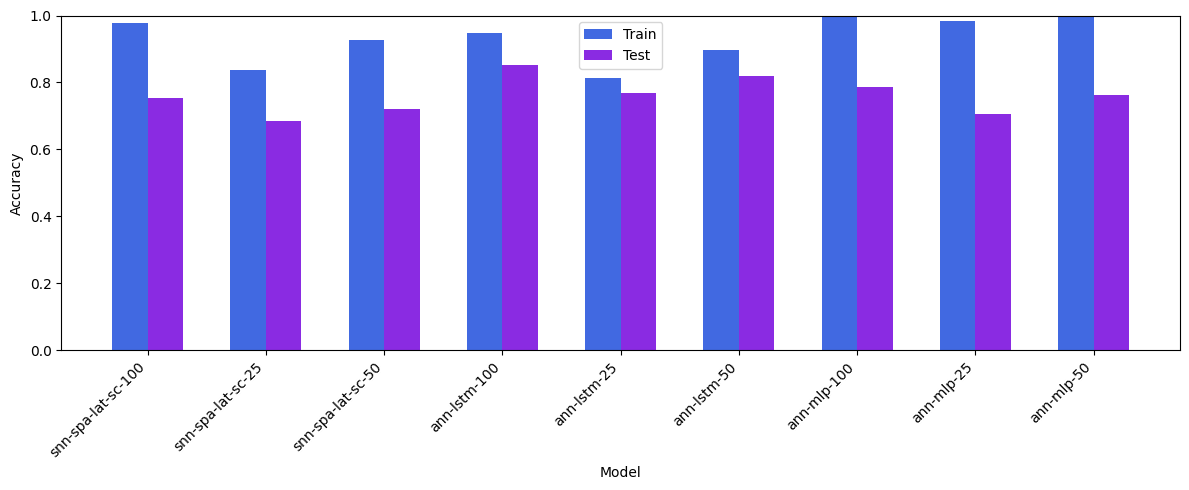

Writing unified accuracies to f:\KU\Thesis\Project\Code\output_results\E_sent\ANN\eval\snn-ann_accuracies.tsv
Model	Train	Test	Energy (nJ/sample)
snn-spa-lat-sc-100	0.9775	0.7530	5741.95
snn-spa-lat-sc-25	0.8375	0.6854	1938.24
snn-spa-lat-sc-50	0.9268	0.7209	3271.41
ann-lstm-100	0.9476	0.8513	215033856.00
ann-lstm-25	0.8139	0.7688	72185856.00
ann-lstm-50	0.8958	0.8197	119801856.00
ann-mlp-100	0.9999	0.7856	16514.83
ann-mlp-25	0.9831	0.7050	5543.95
ann-mlp-50	1.0000	0.7626	9200.91


: 

In [ ]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import numpy as np
from datetime import datetime
from argparse import Namespace
from pprint import pprint

from viz_util import colors, ModelNameConvention
from E_sent_eval import evaluate_model
from ann_util import calculate_ann_total_energy, LSTM_FLOP_Estimate, LSTM_Energy_Estimate

sent_dir = Path(Path.cwd()).parent / 'output_results' / 'E_sent'

# Load SNN .pt files for evaluation
snns_pt = sorted(glob(str(sent_dir / 'main-2' / '*.pt')))

snn_labels = []
snn_train_accuracies = []
snn_test_accuracies = []
snn_energy_nj = []

# Process SNN main-2 models
for pt_file in snns_pt:
    meta_path = Path(pt_file).with_suffix('.json')
    with open(meta_path, 'r', encoding='utf-8') as meta_file:
        data = json.load(meta_file)
    
    label_parts = [data.get('training_config', {}).get('input_mode'), 'lat-sc', str(data.get('training_config', {}).get('embedding_dim'))]
    label = '_'.join(label_parts)
    snn_labels.append('snn-' + ModelNameConvention(label))
    snn_train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    snn_test_accuracies.append(data['results']['test_accuracy'])
    
    # Evaluate model for energy
    meta = data.get('training_config', {})
    args = Namespace(**(meta | {
        "model_path": pt_file,
        "input_file_prefix": f"sent_d{meta.get('embedding_dim', 25)}",
        "diagnose": False,
        "limit": None,
        "split": "test",
        "estimate_energy": True,
        "energy_ac_cost_pj": 25.63,
        "output_json": None,
    }))
    args = Namespace(**{k: (int(v) if isinstance(v, str) and v.isdigit() else v) for k, v in vars(args).items()})
    # pprint(vars(args))
        
    print(f"Evaluating SNN {Path(pt_file).name}...")
    results = evaluate_model(args)
    snn_energy_nj.append(results['avg_energy_pj_per_sample'] / 1000.0)

# Process SNN 50d model from main/
pt_50d = str(sent_dir / 'main' / 'lat_sc_2026-04-30_08-23-34_e-50_s-30_spatial.pt')
json_50d = str(sent_dir / 'main' / 'lat_sc_2026-04-30_08-23-34_e-50_s-30_spatial.json')
with open(json_50d, 'r', encoding='utf-8') as file:
    data = json.load(file)
label_parts = [data.get('training_config', {}).get('input_mode'), 'lat-sc', str(data.get('training_config', {}).get('embedding_dim'))]
label = '_'.join(label_parts)
snn_labels.append('snn-' + ModelNameConvention(label))
snn_train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
snn_test_accuracies.append(data['results']['test_accuracy'])

meta = data.get('training_config', {})
args = Namespace(**(meta | {
    "model_path": pt_50d,
    "input_file_prefix": f"sent_d{meta.get('embedding_dim', 50)}",
    "diagnose": False,
    "limit": None,
    "split": "test",
    "estimate_energy": True,
    "energy_ac_cost_pj": 25.63,
    "output_json": None,
}))
args = Namespace(**{k: (int(v) if isinstance(v, str) and v.isdigit() else v) for k, v in vars(args).items()})

print(f"Evaluating SNN 50d...")
results = evaluate_model(args)
snn_energy_nj.append(results['avg_energy_pj_per_sample'] / 1000.0)

# Load ANN .json files
anns_json = sorted(glob(str(sent_dir / 'ANN' / '*.json')))
if not anns_json:
    raise FileNotFoundError('No matching ANN JSON files found')

ann_labels = []
ann_train_accuracies = []
ann_test_accuracies = []
ann_energy_nj = []

for file_path in anns_json:
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    file_name = Path(file_path).stem
    label_parts = file_name.split('_')[0:3]
    label_parts[-1] = label_parts[-1].replace('d', '')
    label = '-'.join(label_parts)
    ann_labels.append(label)
    ann_train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    ann_test_accuracies.append(data['results']['test_accuracy'])
    
    # Determine if MLP or LSTM and calculate energy
    meta = data.get('training_config', {})
    embedding_dim = meta.get('embedding_dim', 100)
    neurons_per_layer = [embedding_dim * 10, 256, 128, 2]
    
    if 'lstm' in file_name.lower():
        # LSTM energy calculation
        hidden_size = 256 + 128
        lstm_flops = LSTM_FLOP_Estimate(batch_size=1, hidden_size=hidden_size, input_size=embedding_dim, sequence_length=1)
        emac_pj = LSTM_Energy_Estimate(lstm_flops, mode='cpu')
        energy_pj = calculate_ann_total_energy(neurons_per_layer, emac_pj)
    else:
        # MLP energy calculation (default emac_pj)
        energy_pj = calculate_ann_total_energy(neurons_per_layer)
    
    ann_energy_nj.append(energy_pj / 1000.0)  # Convert pJ to nJ

# Combine labels and accuracies
all_labels = snn_labels + ann_labels
all_train_accuracies = snn_train_accuracies + ann_train_accuracies
all_test_accuracies = snn_test_accuracies + ann_test_accuracies
all_energy_nj = snn_energy_nj + ann_energy_nj

# Create unified bar chart
x = np.arange(len(all_labels))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, all_train_accuracies, width, label='Train', color=colors.train_accuracy)
ax.bar(x + width / 2, all_test_accuracies, width, label='Test', color=colors.test_accuracy)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(all_labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

# Output unified TSV
out_dir = sent_dir / 'ANN' / 'eval'
out_dir.mkdir(exist_ok=True)
out_file_path = out_dir / 'snn-ann_accuracies.tsv'
print(f'Writing unified accuracies to {out_file_path}')
with open(out_file_path, 'w', encoding='utf-8') as summary_file:
    summary_file.write('Model\tTrain accuracy\tTest accuracy\tEnergy (nJ/sample)\n')
    for label, train_accuracy, test_accuracy, energy in zip(all_labels, all_train_accuracies, all_test_accuracies, all_energy_nj):
        summary_file.write(f'{label}\t{train_accuracy*100:.2f}\t{test_accuracy*100:.2f}\t{energy:.2f}\n')

print('Model\tTrain\tTest\tEnergy (nJ/sample)')
for label, train_accuracy, test_accuracy, energy in zip(all_labels, all_train_accuracies, all_test_accuracies, all_energy_nj):
    print(f'{label}\t{train_accuracy:.4f}\t{test_accuracy:.4f}\t{energy:.2f}')

# NEURON MODEL

Evaluating ../output_results/E_sent/neuron_model\lat_sc_100_lif_2026-05-12_07-55-49_e-50_s-30_spatial.pt with input prefix sent_d100...
../output_results/E_sent/neuron_model\lat_sc_100_lif_2026-05-12_07-55-49_e-50_s-30_spatial.pt
Evaluation | samples=2085 | loss=1.2192 | acc=0.7530 | eval_time_ms=4077.18
Average AC operations per sample: 229904.55
Average energy per sample: 5892453.35 pJ (5892.4533 nJ)
Evaluating ../output_results/E_sent/neuron_model\lat_sc_100_qlif_2026-05-01_16-21-28_e-50_s-30_spatial.pt with input prefix sent_d100...
../output_results/E_sent/neuron_model\lat_sc_100_qlif_2026-05-01_16-21-28_e-50_s-30_spatial.pt
Evaluation | samples=2085 | loss=1.5181 | acc=0.7353 | eval_time_ms=4178.56
Average AC operations per sample: 411589.25
Average energy per sample: 10549032.07 pJ (10549.0321 nJ)
Evaluating ../output_results/E_sent/neuron_model\lat_sc_100_synaptic_2026-05-01_16-54-20_e-50_s-30_spatial.pt with input prefix sent_d100...
../output_results/E_sent/neuron_model\lat_s

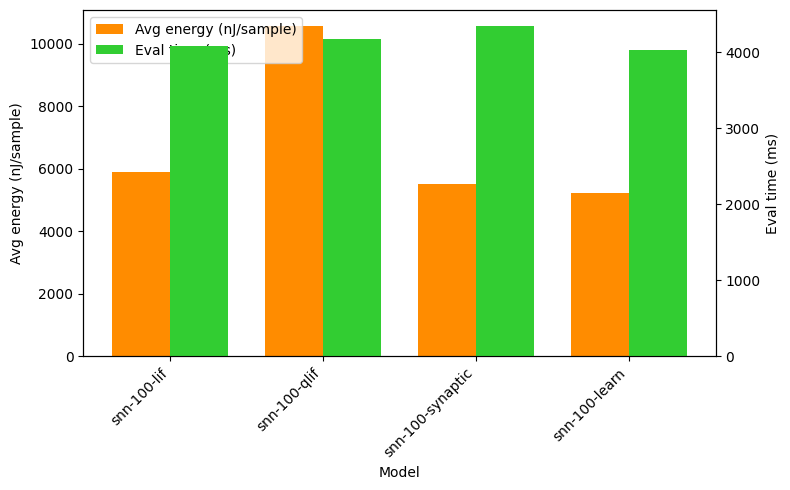

Writing results to ..\output_results\E_sent\neuron_model\eval\accuracies.tsv
Model	Train accuracy	Test accuracy	Energy (nJ/sample)	Eval time (s)	

snn-100-lif	97.93	75.30	5892.45	4.08
snn-100-qlif	93.44	73.53	10549.03	4.18
snn-100-synaptic	99.53	78.71	5514.32	4.34
snn-100-learn	99.36	76.55	5211.56	4.03


In [12]:
from E_sent_eval import evaluate_model
from glob import glob
from pathlib import Path
import json
from argparse import Namespace

import matplotlib.pyplot as plt
import numpy as np
from viz_util import colors

models = sorted(glob('../output_results/E_sent/neuron_model/*.pt'))
# models.append('../output_results/E_sent/main-2/lat_sc_100_2026-04-30_11-03-04_e-50_s-30_spatial.pt') # the LIF 100d model

labels = []
avg_energy_pj_per_sample = []
eval_time_ms = []
last_train_accuracy = []
eval_accuracy = []

for model_path in models:
    meta_path = Path(model_path).with_suffix('.json')
    with open(meta_path, 'r', encoding='utf-8') as meta_file:
        model_data = json.load(meta_file)

    meta = model_data.get('training_config', {})
    input_file_prefix = f"sent_d{meta.get('embedding_dim', 100)}"
    print(f"Evaluating {model_path} with input prefix {input_file_prefix}...")
    args = Namespace(**(meta | {
        "model_path": model_path,
        "input_file_prefix": input_file_prefix,
        "diagnose": False,
        # "diagnose": True,
        # "limit": 10,
        "limit": None,
        "split": "test",
        "estimate_energy": True,
        "energy_ac_cost_pj": 25.63,
        "output_json": None,
    }))
    # Try to cast each number-like argument to int if possible, since JSON doesn't distinguish.
    args = Namespace(**{k: (int(v) if isinstance(v, str) and v.isdigit() else v) for k, v in vars(args).items()})
    print(model_path)
    results = evaluate_model(args)
    labels.append('-'.join(['snn-100', (meta.get('output_file_prefix') or 'lif').split('_')[-1]]))
    avg_energy_pj_per_sample.append(results['avg_energy_pj_per_sample'] / 1000)  # convert pJ to nJ
    eval_time_ms.append(results.get('eval_time_ms', 0))
    last_train_accuracy.append(model_data['results']['epoch_train_accuracy'][-1])
    eval_accuracy.append(results['eval_accuracy'])

positions = np.arange(len(labels))
width = 0.38

fig, ax1 = plt.subplots(figsize=(max(8, len(labels) * 1.2), 5))
ax2 = ax1.twinx()

bars_energy = ax1.bar(positions - width/2, avg_energy_pj_per_sample, width, color=colors.energy, label='Avg energy (nJ/sample)')
bars_time = ax2.bar(positions + width/2, eval_time_ms, width, color=colors.time, label='Eval time (ms)')

ax1.set_xlabel('Model')
ax1.set_ylabel('Avg energy (nJ/sample)')
ax2.set_ylabel('Eval time (ms)')
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.tick_params(axis='y')
ax2.tick_params(axis='y')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

out_dir = Path(models[0]).parent / 'eval'
out_dir.mkdir(exist_ok=True)
out_file_path = out_dir / 'accuracies.tsv'
print(f'Writing results to {out_file_path}')
with open(out_file_path, 'w', encoding='utf-8') as summary_file:
    summary_file.write('Model\tTrain accuracy\tTest accuracy\tEnergy (nJ/sample)\tEval time (s)\n')
    for label, energy_value, time_value, train_acc, test_acc in zip(labels, avg_energy_pj_per_sample, eval_time_ms, last_train_accuracy, eval_accuracy):
        summary_file.write(f'{label}\t{train_acc * 100:.2f}\t{test_acc * 100:.2f}\t{energy_value:.2f}\t{time_value/1000:.2f}\n')

print('Model\tTrain accuracy\tTest accuracy\tEnergy (nJ/sample)\tEval time (s)\t\n')
for label, energy_value, time_value, train_acc, test_acc in zip(labels, avg_energy_pj_per_sample, eval_time_ms, last_train_accuracy, eval_accuracy):
    print(f'{label}\t{train_acc * 100:.2f}\t{test_acc * 100:.2f}\t{energy_value:.2f}\t{time_value/1000:.2f}')